In [2]:
import json
from pathlib import Path

from ultralytics import YOLO


In [3]:
def parse_rfdetr_log(run_dir: Path, label: str):
    """
    Parse rfdetr log.txt and return:
    - full DataFrame
    - summary dict for best epoch by map50_95
    """
    log_path = run_dir / "log.txt"
    assert log_path.exists(), f"Missing log file at {log_path}"

    text = log_path.read_text(encoding="utf-8")

    # if multiple json objects are glued together
    text = text.replace("} {", "}\n{").replace("}{", "}\n{")

    rows = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            rows.append(obj)
        except json.JSONDecodeError:
            continue

    df = pd.DataFrame(rows)

    # keep only entries that have an epoch
    df = df[df["epoch"].notna()].copy()
    df["epoch"] = df["epoch"].astype(int)

    def extract_map(values, idx):
        if isinstance(values, (list, tuple)) and len(values) > idx:
            return float(values[idx])
        return None

    # regular test coco metrics
    df["map50_95"] = df["test_coco_eval_bbox"].apply(lambda v: extract_map(v, 0))
    df["map50"] = df["test_coco_eval_bbox"].apply(lambda v: extract_map(v, 1))

    # ema metrics if available
    if "ema_test_coco_eval_bbox" in df.columns:
        df["ema_map50_95"] = df["ema_test_coco_eval_bbox"].apply(lambda v: extract_map(v, 0))
        df["ema_map50"] = df["ema_test_coco_eval_bbox"].apply(lambda v: extract_map(v, 1))
    else:
        df["ema_map50_95"] = pd.NA
        df["ema_map50"] = pd.NA

    # best epoch by regular map50_95
    best_idx = df["map50_95"].idxmax()
    best = df.loc[best_idx]

    n_params = float(best.get("n_parameters", float("nan")))

    summary = {
        "model": label,
        "family": "RFDETR",
        "params_m": n_params / 1e6,
        "best_epoch": int(best["epoch"]),
        "map50_95": float(best["map50_95"]),
        "map50": float(best["map50"]),
        "ema_map50_95": float(best["ema_map50_95"]) if pd.notna(best["ema_map50_95"]) else None,
        "ema_map50": float(best["ema_map50"]) if pd.notna(best["ema_map50"]) else None,
        "train_loss_best": float(best["train_loss"]),
        "val_loss_best": float(best["test_loss"]),
    }

    return df, summary


In [4]:
root = Path(".")

rfd_small_dir = root / "rfdetr_runs"
rfd_med_dir = root / "rfdetr_runs_medium"

rfd_small_df, rfd_small_summary = parse_rfdetr_log(rfd_small_dir, "RFDETRSmall")
rfd_med_df, rfd_med_summary = parse_rfdetr_log(rfd_med_dir, "RFDETRMedium")


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

YOLO_RESULTS_CSV = Path("yolo11_runs") / "yolo11_chess" / "yolo11s.csv"

yolo_df = pd.read_csv(YOLO_RESULTS_CSV)

print("YOLO columns:")
print(yolo_df.columns)
yolo_df.head()


YOLO columns:
Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,31.6144,0.61290,1.13628,0.87360,0.99357,0.99697,0.99469,0.93300,0.37424,0.29485,0.79095,0.000207,0.000207,0.000207
1,2,43.5927,0.45835,0.38886,0.82250,0.99177,0.99469,0.99463,0.94122,0.34544,0.24490,0.78993,0.000413,0.000413,0.000413
2,3,55.5953,0.43198,0.34273,0.81742,0.99604,0.99986,0.99488,0.93687,0.34849,0.24784,0.79211,0.000616,0.000616,0.000616
3,4,66.9864,0.41813,0.31763,0.81426,0.99683,0.99842,0.99487,0.95049,0.32713,0.23480,0.78718,0.000613,0.000613,0.000613
4,5,78.6729,0.39471,0.29663,0.81081,0.99572,0.99721,0.99493,0.95787,0.30297,0.21407,0.78310,0.000610,0.000610,0.000610


In [6]:
def parse_yolo_run(run_dir: Path, label: str):
    """
    Use yolo11s.csv and best.pt to build a summary for one YOLO run.
    """
    results_csv = run_dir / "yolo11s.csv"
    assert results_csv.exists(), f"Missing yolo11s.csv at {results_csv}"

    df = pd.read_csv(results_csv)

    # column names from Ultralytics
    map_col = "metrics/mAP50-95(B)"
    map50_col = "metrics/mAP50(B)"
    train_loss_col = "train/box_loss"
    val_loss_col = "val/box_loss"

    # best epoch by mAP50 95
    best_idx = df[map_col].idxmax()
    best = df.loc[best_idx]

    # parameter count from fused best model
    weights = run_dir / "weights" / "best.pt"
    assert weights.exists(), f"Missing best.pt at {weights}"

    model = YOLO(str(weights))
    n_params = sum(p.numel() for p in model.model.parameters())

    summary = {
        "model": label,
        "family": "YOLO11",
        "params_m": n_params / 1e6,
        "best_epoch": int(best["epoch"]),
        "map50_95": float(best[map_col]),
        "map50": float(best[map50_col]),
        "ema_map50_95": None,
        "ema_map50": None,
        "train_loss_best": float(best[train_loss_col]),
        "val_loss_best": float(best[val_loss_col]),
    }

    return df, summary


In [7]:
yolo_root = root / "yolo11_runs"

yolo_s_dir = yolo_root / "yolo11_chess"
yolo_m_dir = yolo_root / "yolo11m_chess"
yolo_l_dir = yolo_root / "yolo11l_chess"

yolo_s_df, yolo_s_summary = parse_yolo_run(yolo_s_dir, "YOLO11s")
yolo_m_df, yolo_m_summary = parse_yolo_run(yolo_m_dir, "YOLO11m")
yolo_l_df, yolo_l_summary = parse_yolo_run(yolo_l_dir, "YOLO11l")


In [8]:
summary_df = pd.DataFrame(
    [
        rfd_small_summary,
        rfd_med_summary,
        yolo_s_summary,
        yolo_m_summary,
        yolo_l_summary,
    ]
)

summary_df


,model,family,params_m,best_epoch,map50_95,map50,ema_map50_95,ema_map50,train_loss_best,val_loss_best
0,RFDETRSmall,RFDETR,31.830526,36,0.965829,0.999862,0.967373,0.999872,1.232171,1.153590
1,RFDETRMedium,RFDETR,33.406814,36,0.966832,0.999917,0.970213,0.999954,1.440113,1.365357
2,YOLO11s,YOLO11,9.432436,39,0.975680,0.994810,NaN,NaN,0.244370,0.242690
3,YOLO11m,YOLO11,20.062260,66,0.976860,0.994790,NaN,NaN,0.207120,0.226280
4,YOLO11l,YOLO11,25.319732,31,0.976760,0.994870,NaN,NaN,0.262220,0.241190


In [ ]:
summary_df.to_csv("model_summary_all_runs.csv", index=False)

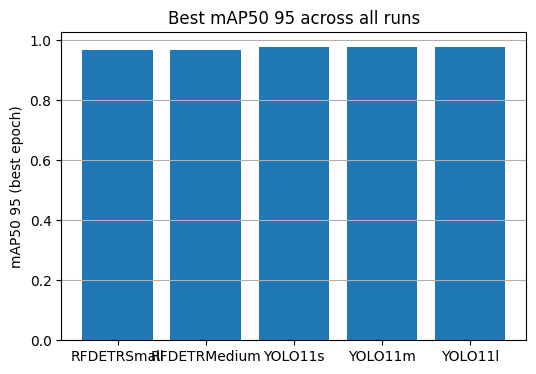

In [36]:
plt.figure(figsize=(6, 4))
plt.bar(summary_df["model"], summary_df["map50_95"])
plt.ylabel("mAP50 95 (best epoch)")
plt.title("Best mAP50 95 across all runs")
plt.grid(axis="y")
plt.show()
